In [1]:
import hist as h
import dask
import awkward as ak
import hist.dask as dhist
import dask_awkward as dak
import uproot
import numpy as np
import mplhep as mh
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import matplotlib.pyplot as plt
import vector
vector.register_awkward()

NanoAODSchema.warn_missing_crossrefs = False

In [2]:
events = NanoEventsFactory.from_root(
    {"../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_1M.root": "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

dask.awkward<from-uproot, npartitions=1>

In [3]:
# Defining the style for plots (CMS Style)
from mplhep.plot import AnchoredText
plt.style.use(mh.style.CMS)
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

In [4]:
# Histogram Function:
def make_hist(
        data, nBins, lo, hi, xlabel, ylabel, label, fname=None, logy=False, ax=None, show=True, return_hist=False, show_stats=True, histtype='step'
):
    histogram = dhist.Hist(h.axis.Regular(nBins, lo, hi))
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(7, 5))
    else:
        fig = ax.figure
    histogram.fill(data)
    hist_comp = histogram.compute()

    mh.histplot(hist_comp, ax=ax, label=label, histtype=histtype, lw=1)
    mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    # log scale option:
    if logy:
        ax.set_yscale("log")

    # Statbox option:
    if show_stats:
        n_entries = len(data.compute())
        mean_val = np.mean(data.compute())
        std_val = np.std(data.compute())
        stat_text = (f"Entries: {n_entries}\n"
                     f"Mean:    {mean_val:.2f}\n"
                     f"Std Dev: {std_val:.2f}")
        at = AnchoredText(stat_text, prop=dict(size=10), frameon=True, loc="center right")
        ax.add_artist(at)

    # Save figure option:
    if fname:
        plt.savefig(fname)

    # Show figure option:
    if show:
        plt.show()

    if return_hist:
        return fig, ax, hist_comp
    return fig, ax

In [5]:
# Making Difference Histogram Function:
def make_diff_hist(
    a, b, *, bins=50, lo=0, hi=200, ylo=-1, yhi=2000, name="x",
    xlabel=None, ylabel="Entries", title=None, diff_label="A - B", color="k", histtype="errorbar", yerr=False, zero_line=True, normalize=False, weights_a=None,weights_b=None, flatten=False, cms_label=True, ax=None,
    figsize=(7, 5), grid=True, show=True, fname=None,
    return_hists=False,
):
    # Detect hist input
    try:
        from hist.basehist import BaseHist
        a_is_hist = isinstance(a, BaseHist)
        b_is_hist = isinstance(b, BaseHist)
    except Exception:
        a_is_hist = False
        b_is_hist = False

    def _prep(x):
        if flatten:
            try:
                return dak.flatten(x)
            except Exception:
                return x
        return x

    # Build/obtain hA and hB
    if a_is_hist and b_is_hist:
        hA = a
        hB = b
    elif (not a_is_hist) and (not b_is_hist):
        axis = h.axis.Regular(
            bins, lo, hi,
            name=name,
            label=(xlabel if xlabel is not None else name),
        )
        hA_d = h.dask.Hist(axis)
        hB_d = h.dask.Hist(axis)

        xA = _prep(a)
        xB = _prep(b)

        if weights_a is None:
            hA_d.fill(**{name: xA})
        else:
            hA_d.fill(**{name: xA}, weight=_prep(weights_a))

        if weights_b is None:
            hB_d.fill(**{name: xB})
        else:
            hB_d.fill(**{name: xB}, weight=_prep(weights_b))

        hA = hA_d.compute()
        hB = hB_d.compute()
    else:
        raise TypeError("make_diff_hist: both inputs must be arrays OR both must be hist objects.")

    if normalize:
        sA = float(hA.values().sum())
        sB = float(hB.values().sum())
        if sA > 0:
            hA = hA / sA
        if sB > 0:
            hB = hB / sB

    hDiff = hA - hB

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if cms_label:
        mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

    mh.histplot(hDiff, ax=ax, label=diff_label, histtype=histtype, color=color, yerr=yerr)

    if zero_line:
        ax.axhline(0.0, color="0.5", lw=1, linestyle="--")

    if title:
        ax.set_title(title)

    ax.set_xlabel(xlabel if xlabel is not None else name)
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylo, yhi)
    ax.legend()
    if grid:
        ax.grid(True, alpha=0.3)
    if fname:
        plt.savefig(fname)
    if show:
        plt.show()

    if return_hists:
        return fig, ax, hDiff, hA, hB
    return fig, ax, hDiff

In [6]:
# Overlay Histogram Function:
def make_overlay_hist(
    data_a, data_b, *, bins=50, x_range=(0, 200), name="x",
    histtype="step", xlabel=None, ylabel=None, title=None,
    normalize=True, labels=("A", "B"), colors=("C0", "C1"),
    weights_a=None, weights_b=None, flatten=False, cms_label=True, ax=None, figsize=(7, 5), grid=True,
    fname=None, show=True, yerr=False, linewidth=1.5,     
):
    def _prep(x):
        if flatten:
            try:
                return dak.flatten(x)
            except Exception:
                return x
        return x

    axis = h.axis.Regular(
        bins, x_range[0], x_range[1],
        name=name,
        label=(xlabel if xlabel is not None else name),
    )

    hA_d = h.dask.Hist(axis)
    hB_d = h.dask.Hist(axis)

    xA = _prep(data_a)
    xB = _prep(data_b)

    if weights_a is None:
        hA_d.fill(**{name: xA})
    else:
        hA_d.fill(**{name: xA}, weight=_prep(weights_a))

    if weights_b is None:
        hB_d.fill(**{name: xB})
    else:
        hB_d.fill(**{name: xB}, weight=_prep(weights_b))

    hA = hA_d.compute()
    hB = hB_d.compute()

    if normalize:
        sA = float(hA.values().sum())
        sB = float(hB.values().sum())
        if sA > 0:
            hA = hA / sA
        if sB > 0:
            hB = hB / sB

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    mh.histplot(
        hA,
        ax=ax,
        label=labels[0],
        color=colors[0],
        histtype=histtype,
        yerr=yerr,
        linewidth=linewidth if histtype == "step" else None,
    )
    mh.histplot(
        hB,
        ax=ax,
        label=labels[1],
        color=colors[1],
        histtype=histtype,
        yerr=yerr,
        linewidth=linewidth if histtype == "step" else None,
    )

    if cms_label:
        mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

    if title:
        ax.set_title(title)

    ax.set_xlabel(xlabel if xlabel is not None else name)
    ax.set_ylabel(
        ylabel if ylabel is not None else ("Normalized entries" if normalize else "Entries")
    )
    ax.legend()
    if grid:
        ax.grid(True, alpha=0.3)
    if fname:
        plt.savefig(fname)
    if show:
        plt.show()

    return fig, ax, hA, hB

In [7]:
def os_ss_hist(x_os, x_ss, *, bins=20, lo=20, hi=200, name="pt", label=None, normalize=False):
    axis = h.axis.Regular(bins, lo, hi, name=name, label=(label if label else name))
    hOS_d = h.dask.Hist(axis)
    hSS_d = h.dask.Hist(axis)
    hOS_d.fill(**{name: x_os})
    hSS_d.fill(**{name: x_ss})
    hDiff = hOS_d.compute() - hSS_d.compute()
    if normalize:
        s = float(hDiff.values().sum())
        if s != 0:
            hDiff = hDiff / s
    return hDiff

In [8]:
# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet

# W -> Mu Nu Channel Selection:
W_MuMask = (
    (Muon.pt > 30) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == True) &
    (Muon.pfRelIso04_all < 0.15)
    )
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]
# Select events with exactly one W muon:
nMu = dak.num(W_Muons.pt)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

###############################################
## C-jet -> Mu X Channel Selection (soft muon)
###############################################

cMuPassCuts = (
    (Muon.pt < 25) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) & 
    (Muon.tightId == 1)
 )
soft_muon = Muon[cMuPassCuts]

# Impact parameter significance cut (2D)
# Nominal cut: > 2 ; systematic variation: > 1
ipSigCut_nom = 2.0
ipSigCut_syst = 1.0  # optional systematic variation

dxy_err_ok = (soft_muon.dxyErr > 0)
sip2d = abs(soft_muon.dxy) / soft_muon.dxyErr

# choose ONE of these masks depending on what you want to run
ipSigMask = dxy_err_ok & (sip2d > ipSigCut_nom)
# ipSigMask = dxy_err_ok & (sip2d > ipSigCut_syst)  # systematic alternative

soft_muon = soft_muon[ipSigMask]

###############################################
## dR matching (soft muon <-> jets)
## - builds all muon-jet pairs per event
## - picks nearest jet per muon
## - requires min dR < dr_cut
###############################################

dr_cut = 0.4

# Jets eligible for matching (apply your jet kinematic cuts here)
jets_for_match = Jet[
    (Jet.pt > 30) &
    (abs(Jet.eta) < 2.4)
 ]

# Pairwise muon-jet combinations within each event: (evt, nMu, nJet)
pairs = dak.cartesian({"mu": soft_muon, "jet": jets_for_match}, nested=True)

# Calculate deltaR for each muon-jet pair (phi wrapping handled internally)
dr_pairs = pairs["mu"].delta_r(pairs["jet"])

# Nearest jet per muon (handles events with 0 jets by returning None)
min_dr = dak.min(dr_pairs, axis=2)
best_jet_idx = dak.argmin(dr_pairs, axis=2)

# Require a valid match within dr_cut
min_dr_filled = dak.fill_none(min_dr, np.inf)
has_match = (min_dr_filled < dr_cut)

# Keep only matched soft muons and their matched jets
soft_muon_in_goodjet = soft_muon[has_match]
c_Jets = jets_for_match[best_jet_idx]
c_Jets = c_Jets[has_match]

nC_Jets = dak.num(c_Jets.pt)
# Select events with atleast one c-jet:
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

In [9]:
W_Muons_Pt = dak.flatten(W_Muons.pt)
cJet_Pt = dak.flatten(c_Jets.pt)

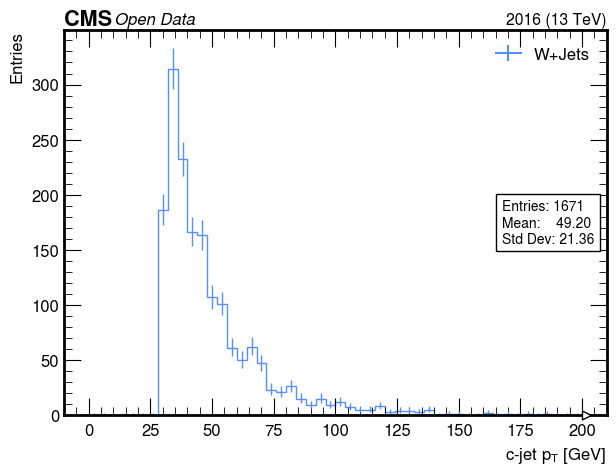

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='c-jet $p_{T}$ [GeV]', ylabel='Entries'>,
 Hist(Regular(50, 0, 200, label='Axis 0'), storage=Double()) # Sum: 1670.0 (1671.0 with flow))

In [10]:
make_hist(
    data=cJet_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="c-jet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+Jets",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=True,
    show_stats=True,
    histtype='step'
)

In [ ]:
make_hist(
    W_Muons_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="W Muon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)

In [ ]:
# W -> Mu Nu Channel Selection:
W_MuMask = (
    (Muon.pt > 30) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == True) &
    (Muon.pfRelIso04_all < 0.15)
    )
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]
# Select events with exactly one W muon:
nMu = dak.num(W_Muons.pt)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

# C-jet -> Mu X Channel Selection:
cMuPassCuts = (
    (Muon.pt < 20) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) &
    (Muon.tightId == 1)
)
soft_muon = Muon[cMuPassCuts]

# Impact parameter significance cut (2D)
# Nominal cut: > 2 ; systematic variation: > 1
ipSigCut_nom = 2.0
ipSigCut_syst = 1.0  # optional systematic variation

dxy_err_ok = (soft_muon.dxyErr > 0)
sip2d = abs(soft_muon.dxy) / soft_muon.dxyErr

# choose ONE of these masks depending on what you want to run
ipSigMask = dxy_err_ok & (sip2d > ipSigCut_nom)
# ipSigMask = dxy_err_ok & (sip2d > ipSigCut_syst)  # systematic alternative

soft_muon = soft_muon[ipSigMask]

# Require the muon be matched to a jet (jetIdx >= 0)
soft_muon_injet = soft_muon[soft_muon.jetIdx >= 0]

# Get the matched jet for each selected muon
matched_jet = Jet[soft_muon_injet.jetIdx]

# Apply jet cuts on the *matched jets*
Jet_PassCuts = (
    (matched_jet.pt > 30) & 
    (abs(matched_jet.eta) < 2.4)
)

# Keep only muons whose matched jet passes jet cuts
soft_muon_in_goodjet = soft_muon_injet[Jet_PassCuts]
c_Jets = matched_jet[Jet_PassCuts]
nC_Jets = dak.num(c_Jets.pt)
# Select events with atleast one c-jet:
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

In [ ]:
W_Muons_Pt = dak.flatten(W_Muons.pt)
cJet_Pt = dak.flatten(c_Jets.pt)

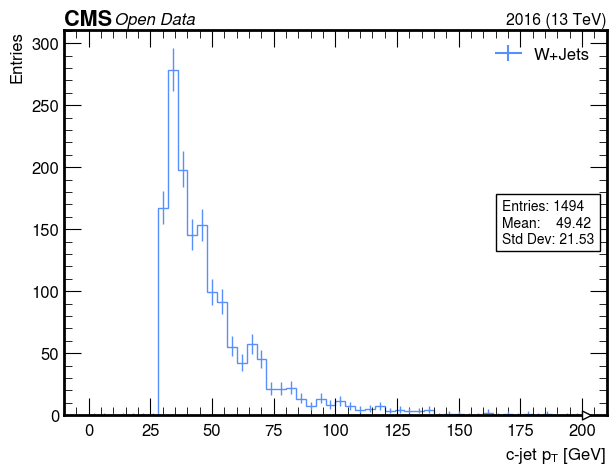

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='c-jet $p_{T}$ [GeV]', ylabel='Entries'>,
 Hist(Regular(50, 0, 200, label='Axis 0'), storage=Double()) # Sum: 1493.0 (1494.0 with flow))

In [ ]:
make_hist(
    data=cJet_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="c-jet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+Jets",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=True,
    show_stats=True,
    histtype='step'
)

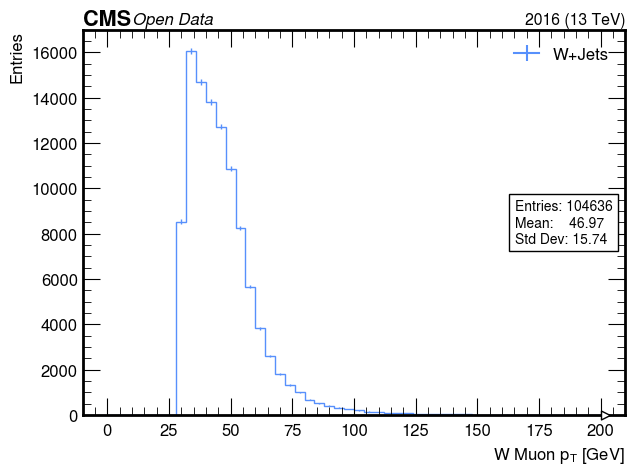

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='W Muon $p_{T}$ [GeV]', ylabel='Entries'>,
 Hist(Regular(50, 0, 200, label='Axis 0'), storage=Double()) # Sum: 104587.0 (104636.0 with flow))

In [ ]:
make_hist(
    W_Muons_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="W Muon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)